In [11]:
# STEP 1: import dependencies

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle

print(f"Dependencies imported successfully!")

Dependencies imported successfully!


LOAD THE DATASET


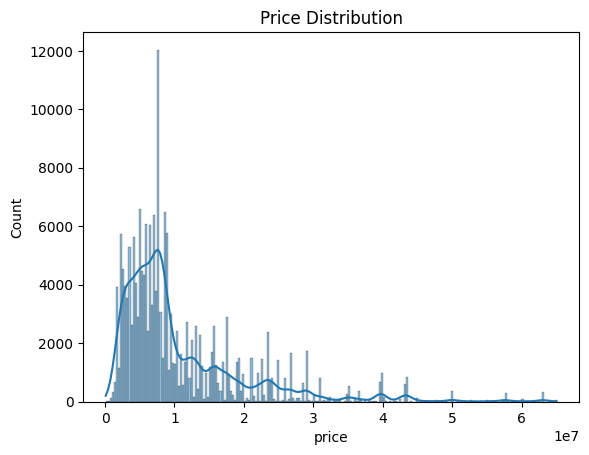

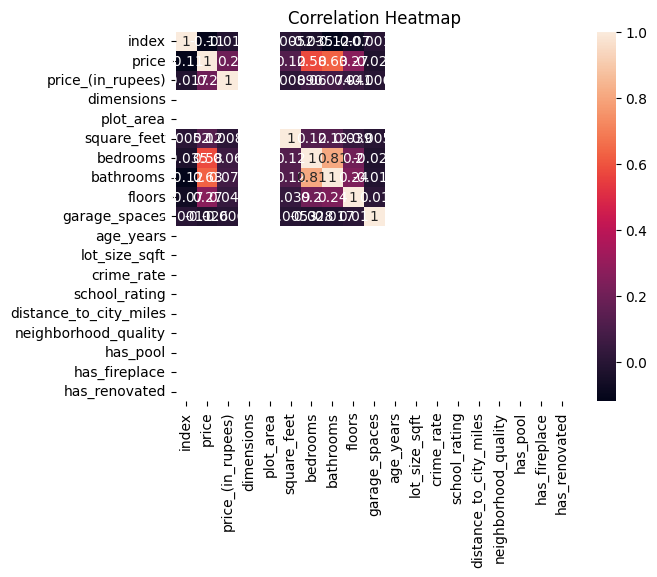

In [12]:
# STEP 2.1: load the Dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("="*60)
print("LOAD THE DATASET")
print("="*60)

df = pd.read_csv('house_price_indian.csv')

# Normalize column names
# (Note: this dataset contains both "amount(in rupees)" and "price_(in rupees)".
#  The former is the actual sale value; the latter is often a per-sqft rate.)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Determine which column to use as the target (sale price)
TARGET_CANDIDATES = [
    'amount(in_rupees)',      # primary sale price column in this dataset
    'price_(in_rupees)',      # secondary/alternate price column
    'price',                  # already normalized
]

target_col = next((c for c in TARGET_CANDIDATES if c in df.columns), None)
if target_col is None:
    raise KeyError(
        "No price column found in dataset. Expected one of: " + ", ".join(TARGET_CANDIDATES)
    )

# Canonicalize the target column name to 'price'
if target_col != 'price':
    df = df.rename(columns={target_col: 'price'})

# Helper functions
def parse_number(value):
    try:
        if pd.isna(value):
            return np.nan
        filtered = ''.join(ch for ch in str(value) if (ch.isdigit() or ch == '.' or ch == '-'))
        return float(filtered) if filtered not in ['', '.', '-', '-.'] else np.nan
    except:
        return np.nan


def parse_indian_currency(value):
    """Parse Indian-style monetary strings into numeric rupees."""
    if pd.isna(value):
        return np.nan

    s = str(value).strip().lower()

    # Remove common currency characters
    for token in ['₹', 'rs', 'inr', ',', ' ']:
        s = s.replace(token, '')

    import re
    m = re.match(r'^([0-9]*\.?[0-9]+)([a-zA-Z]*)$', s)
    if not m:
        return parse_number(value)

    num = float(m.group(1))
    suffix = m.group(2)

    multipliers = {
        'k': 1e3,
        'thousand': 1e3,
        'l': 1e5,
        'lac': 1e5,
        'lakh': 1e5,
        'cr': 1e7,
        'crore': 1e7,
        'm': 1e6,
        'million': 1e6,
        'b': 1e9,
        'billion': 1e9,
    }

    return num * multipliers.get(suffix, 1)


def parse_bhk(title):
    if pd.isna(title):
        return np.nan
    import re
    match = re.search(r"(\d+)\s*bhk", str(title).lower())
    return float(match.group(1)) if match else np.nan


# Feature Engineering
if 'carpet_area' in df.columns:
    df['square_feet'] = df['carpet_area'].apply(parse_number)

df['bedrooms'] = df.get('title', pd.Series(dtype='float')).apply(parse_bhk)

if 'bathroom' in df.columns:
    df['bathrooms'] = df['bathroom'].apply(parse_number)

if 'floor' in df.columns:
    df['floors'] = df['floor'].apply(lambda v: parse_number(str(v).split()[0]))

if 'car_parking' in df.columns:
    df['garage_spaces'] = df['car_parking'].apply(parse_number)


# Add missing columns
for col in [
    'age_years','lot_size_sqft','crime_rate','school_rating',
    'distance_to_city_miles','neighborhood_quality',
    'has_pool','has_fireplace','has_renovated',
]:
    if col not in df.columns:
        df[col] = np.nan


# Convert target
if 'price' in df.columns:
    df['price'] = df['price'].apply(parse_indian_currency)


# FIXED MISSING VALUE HANDLING
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if df[col].isnull().all():
        # Column is fully empty → fill with 0
        df[col] = df[col].fillna(0)
    else:
        # Normal case → fill with median
        df[col] = df[col].fillna(df[col].median())


# Remove duplicates
df = df.drop_duplicates()


# Outlier handling
if 'price' in df.columns:
    upper_limit = df['price'].quantile(0.99)
    df = df[df['price'] <= upper_limit]


# Visualization 1
plt.figure()
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.show()


# Visualization 2
plt.figure()
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()


EXPLORATORY DATA ANALYSIS

Price Statistics : 
Mean price: ₹10,804,766.50
Median price: ₹7,800,000.00
Min price: ₹100,000.00
Max price: ₹65,000,000.00
Std Dev : ₹9,423,913.28


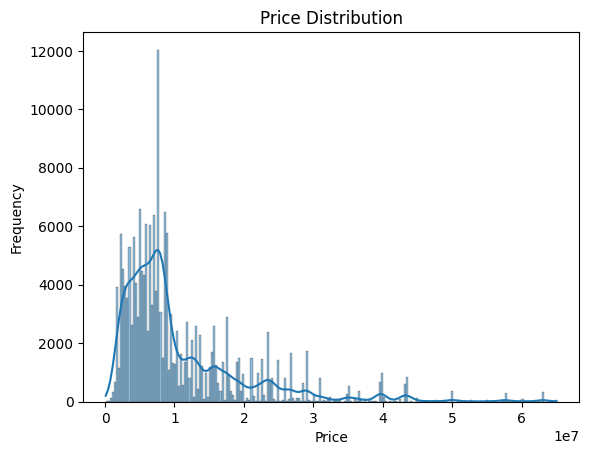


CORRELATION ANALYSIS

Features correlation with price: 
price                     1.000000
bathrooms                 0.628557
bedrooms                  0.575514
floors                    0.265974
price_(in_rupees)         0.198987
square_feet               0.120506
garage_spaces            -0.026273
index                    -0.114943
dimensions                     NaN
plot_area                      NaN
age_years                      NaN
lot_size_sqft                  NaN
crime_rate                     NaN
school_rating                  NaN
distance_to_city_miles         NaN
neighborhood_quality           NaN
has_pool                       NaN
has_fireplace                  NaN
has_renovated                  NaN
Name: price, dtype: float64

Highly correlated features (|correlation| > 0.5):
bathrooms    0.628557
bedrooms     0.575514
Name: price, dtype: float64


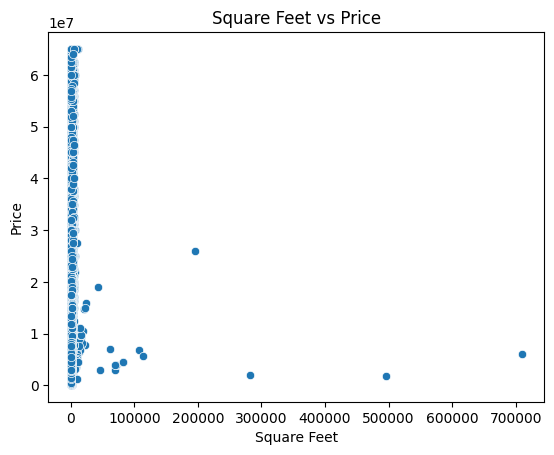

In [13]:
# STEP 3: Exploratory Data Analysis

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS")
print("="*60)

# Ensure price column is clean
df = df[df['price'].notna()]

# Price Statistics
print(f'\nPrice Statistics : ')
print(f"Mean price: ₹{df['price'].mean():,.2f}")
print(f"Median price: ₹{df['price'].median():,.2f}")
print(f"Min price: ₹{df['price'].min():,.2f}")
print(f"Max price: ₹{df['price'].max():,.2f}")
print(f"Std Dev : ₹{df['price'].std():,.2f}")


# Visualization 1: Price Distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


# Correlation Analysis (SAFE)
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Only numeric columns
numeric_df = df.select_dtypes(include='number')

correlations = numeric_df.corr()['price'].sort_values(ascending=False)

print(f'\nFeatures correlation with price: ')
print(correlations)


# Highly correlated features
high_corr = correlations[abs(correlations) > 0.5].drop('price', errors='ignore')

print(f'\nHighly correlated features (|correlation| > 0.5):')
print(high_corr)


# Visualization 2 (NEW): Scatter Plot
# Relationship between size and price (VERY IMPORTANT FEATURE)
if 'square_feet' in df.columns:
    plt.figure()
    sns.scatterplot(x='square_feet', y='price', data=df)
    plt.title("Square Feet vs Price")
    plt.xlabel("Square Feet")
    plt.ylabel("Price")
    plt.show()


In [14]:
# STEP 4: Data preparation / train-test split

print("\n" + "="*60)
print("DATA PREPARATION")
print("="*60)

# Define target and feature set
TARGET_COL = 'price'

# Use numeric columns as a baseline feature set (excluding the target)
feature_cols = [c for c in df.select_dtypes(include='number').columns if c != TARGET_COL]

# Drop index-like columns that don't carry predictive value
for drop_col in ['index', 'id', 'serial', 'unnamed: 0']:
    if drop_col in feature_cols:
        feature_cols.remove(drop_col)

X = df[feature_cols].copy()
y = df[TARGET_COL].copy()

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Impute missing values (should be minimal after earlier filling)
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Save expected feature order for later (serialization / inference)
expected_features = feature_cols

print(f"Features used for modeling ({len(expected_features)}): {expected_features}")



DATA PREPARATION
Features used for modeling (17): ['price_(in_rupees)', 'dimensions', 'plot_area', 'square_feet', 'bedrooms', 'bathrooms', 'floors', 'garage_spaces', 'age_years', 'lot_size_sqft', 'crime_rate', 'school_rating', 'distance_to_city_miles', 'neighborhood_quality', 'has_pool', 'has_fireplace', 'has_renovated']



MODEL TRAINING

[1/3] Training Linear Regression...
✔ Linear Regression Trained

[2/3] Training Random Forest...
✔ Random Forest Trained

[3/3] Training Gradient Boosting...
✔ Gradient Boosting Trained

All models trained successfully!

MODEL EVALUATION

Linear Regression:
R2 Score: 0.4607
MAE: ₹4,769,551.72
RMSE: ₹6,871,772.64

Random Forest:
R2 Score: 0.9641
MAE: ₹541,739.50
RMSE: ₹1,772,242.15

Gradient Boosting:
R2 Score: 0.9533
MAE: ₹988,583.20
RMSE: ₹2,021,669.28


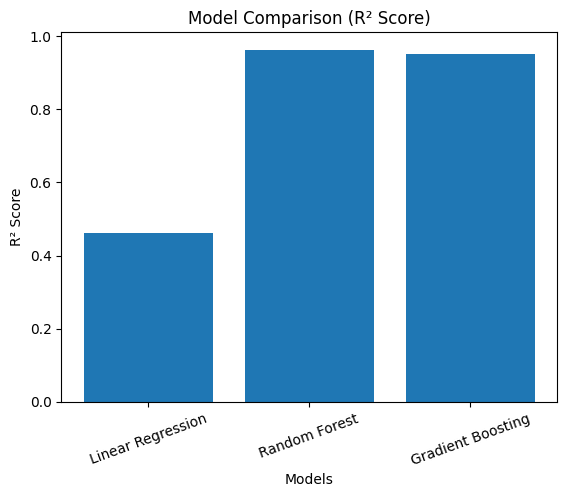

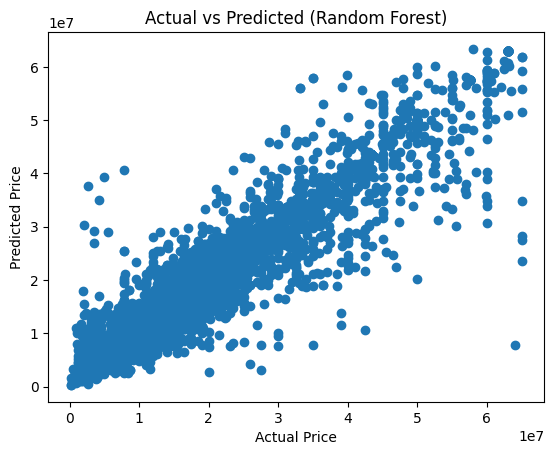


Best Model: Random Forest


In [15]:
# STEP 5: Modle training

print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

models = {}
results = {}

# MODEL 1: Linear Regression
print("\n[1/3] Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
models['Linear Regression'] = lr_model
print("✔ Linear Regression Trained")


# MODEL 2: Random Forest
print("\n[2/3] Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
print("✔ Random Forest Trained")


# MODEL 3: Gradient Boosting
print("\n[3/3] Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb_model
print("✔ Gradient Boosting Trained")


print("\nAll models trained successfully!")


# MODEL EVALUATION
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = r2

    print(f"\n{name}:")
    print(f"R2 Score: {r2:.4f}")
    print(f"MAE: ₹{mae:,.2f}")
    print(f"RMSE: ₹{rmse:,.2f}")


# Visualization 1: Model Comparison (NEW)
plt.figure()
model_names = list(results.keys())
scores = list(results.values())

plt.bar(model_names, scores)
plt.title("Model Comparison (R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()


# Visualization 2: Actual vs Predicted (BEST MODEL)
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)

plt.figure()
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()


print(f"\nBest Model: {best_model_name}")


MODEL EVALUATION

Evaluation: Linear Regression

Training Performance:
R2 Score : 0.4417
RMSE     : ₹7,053,925.54
MAE      : ₹4,791,230.13

Testing Performance:
R2 Score : 0.4607
RMSE     : ₹6,871,772.64
MAE      : ₹4,769,551.72

 Good generalization (difference: -0.0190)

Evaluation: Random Forest

Training Performance:
R2 Score : 0.9919
RMSE     : ₹849,767.56
MAE      : ₹295,288.84

Testing Performance:
R2 Score : 0.9641
RMSE     : ₹1,772,242.15
MAE      : ₹541,739.50

 Good generalization (difference: 0.0278)

Evaluation: Gradient Boosting

Training Performance:
R2 Score : 0.9599
RMSE     : ₹1,890,355.44
MAE      : ₹957,526.00

Testing Performance:
R2 Score : 0.9533
RMSE     : ₹2,021,669.28
MAE      : ₹988,583.20

 Good generalization (difference: 0.0066)

MODEL COMPARISON SUMMARY

Model               Test R2     Test RMSE      Test MAE       
-----------------------------------------------------------------
Linear Regression   0.4607      6871772.64     4769551.72     
Random Fore

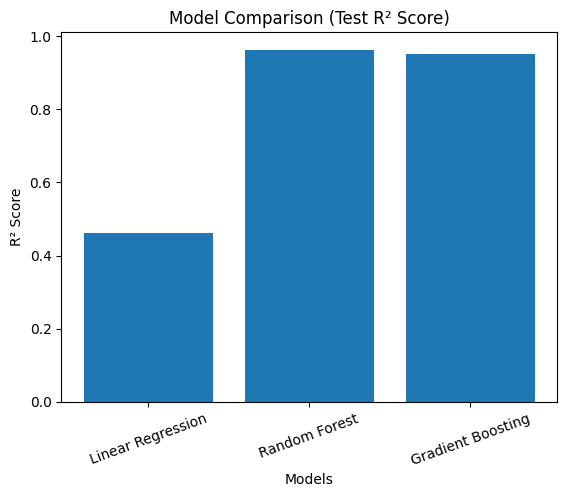

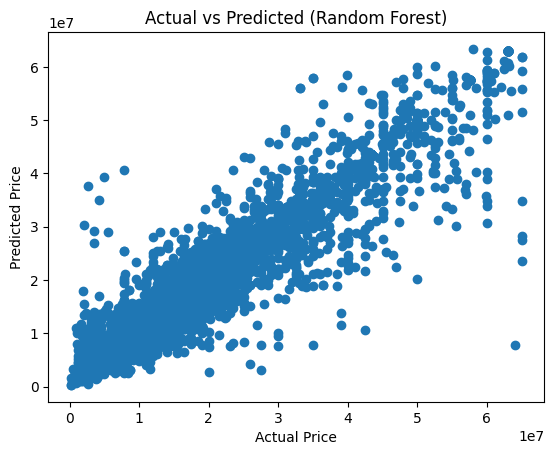

In [16]:
# STEP 6: Model Evaluation

print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

results = {}

for name, model in models.items():
    print("\n" + "="*60)
    print(f"Evaluation: {name}")
    print("="*60)

    # Predictions
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    # Training Metrics
    train_r2 = r2_score(y_train, y_train_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    train_mae = mean_absolute_error(y_train, y_train_pred)

    # Testing Metrics
    test_r2 = r2_score(y_test, y_test_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    test_mae = mean_absolute_error(y_test, y_test_pred)

    # Store results
    results[name] = {
        'train_r2': train_r2,
        'test_r2': test_r2,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'train_mae': train_mae,
        'test_mae': test_mae,
    }

    # Print Training Performance
    print("\nTraining Performance:")
    print(f"R2 Score : {train_r2:.4f}")
    print(f"RMSE     : ₹{train_rmse:,.2f}")
    print(f"MAE      : ₹{train_mae:,.2f}")

    # Print Testing Performance
    print("\nTesting Performance:")
    print(f"R2 Score : {test_r2:.4f}")
    print(f"RMSE     : ₹{test_rmse:,.2f}")
    print(f"MAE      : ₹{test_mae:,.2f}")

    # Overfitting Check
    overfit_diff = train_r2 - test_r2
    if overfit_diff > 0.1:
        print(f"\n Possible overfitting (difference: {overfit_diff:.4f})")
    else:
        print(f"\n Good generalization (difference: {overfit_diff:.4f})")


# SUMMARY TABLE
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

print(f"\n{'Model':<20}{'Test R2':<12}{'Test RMSE':<15}{'Test MAE':<15}")
print("-"*65)

for name, metrics in results.items():
    print(f"{name:<20}{metrics['test_r2']:<12.4f}{metrics['test_rmse']:<15.2f}{metrics['test_mae']:<15.2f}")


# BEST MODEL
best_model_name = max(results, key=lambda x: results[x]['test_r2'])
best_model = models[best_model_name]

print("\n" + "="*60)
print(f"Best Model: {best_model_name}")
print(f"Test R2 Score: {results[best_model_name]['test_r2']:.4f}")
print("="*60)


# Visualization 1: Model Comparison (R2)
plt.figure()
model_names = list(results.keys())
test_r2_scores = [results[m]['test_r2'] for m in model_names]

plt.bar(model_names, test_r2_scores)
plt.title("Model Comparison (Test R² Score)")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=20)
plt.show()


# Visualization 2: Actual vs Predicted (Best Model)
y_pred_best = best_model.predict(X_test_scaled)

plt.figure()
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted ({best_model_name})")
plt.show()


STEP 7: MODEL SERIALIZATION

Saving the best model: Random Forest
✔ Model saved as 'house_price_model.pkl'

Saving scaler...
✔ Scaler saved as 'scaler.pkl'

Saving imputer...
✔ Imputer saved as 'imputer.pkl'
✔ Feature names saved
✔ Metadata saved successfully

Verifying saved model...
✔ Model loaded successfully. Sample prediction: ₹8,496,314.35


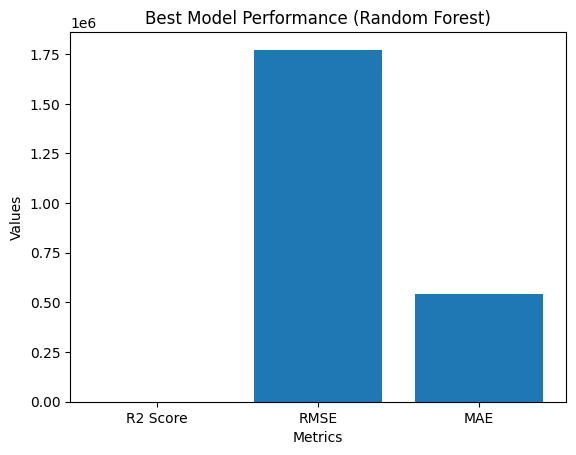


MODEL TRAINING COMPLETE!

Files created:
 1. house_price_model.pkl - Trained model
 2. scaler.pkl - Feature Scaler
 3. imputer.pkl - Missing value handler
 4. feature_names.pkl - Feature names
 5. model_metadata.pkl - Model information


In [17]:
# STEP 7: Save model (Serialization)

print("\n" + "="*60)
print("STEP 7: MODEL SERIALIZATION")
print("="*60)

# Save Best Model
model_filename = 'house_price_model.pkl'
scaler_filename = 'scaler.pkl'
imputer_filename = 'imputer.pkl'

print(f"\nSaving the best model: {best_model_name}")

with open(model_filename, 'wb') as file:
    pickle.dump(best_model, file)

print(f"✔ Model saved as '{model_filename}'")


# Save Scaler
print("\nSaving scaler...")
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)

print(f"✔ Scaler saved as '{scaler_filename}'")


# Save Imputer (IMPORTANT FIX)
print("\nSaving imputer...")
with open(imputer_filename, 'wb') as file:
    pickle.dump(imputer, file)

print(f"✔ Imputer saved as '{imputer_filename}'")


# Save Feature Names
feature_names = expected_features   # better than X.columns

with open('feature_names.pkl', 'wb') as file:
    pickle.dump(feature_names, file)

print(f"✔ Feature names saved")


# Save Metadata
metadata = {
    'model_name': best_model_name,
    'test_rmse': results[best_model_name]['test_rmse'],
    'test_r2': results[best_model_name]['test_r2'],
    'test_mae': results[best_model_name]['test_mae'],
    'features': feature_names,
    'training_samples': len(X_train),
    'testing_samples': len(X_test)
}

with open('model_metadata.pkl', 'wb') as file:
    pickle.dump(metadata, file)

print("✔ Metadata saved successfully")


# Verification (Load & Test)
print("\nVerifying saved model...")

with open(model_filename, 'rb') as file:
    loaded_model = pickle.load(file)

sample_prediction = loaded_model.predict(X_test_scaled[:1])
print(f"✔ Model loaded successfully. Sample prediction: ₹{sample_prediction[0]:,.2f}")


# Visualization: Model Metrics Summary
plt.figure()

metrics_names = ['R2 Score', 'RMSE', 'MAE']
values = [
    results[best_model_name]['test_r2'],
    results[best_model_name]['test_rmse'],
    results[best_model_name]['test_mae']
]

plt.bar(metrics_names, values)
plt.title(f"Best Model Performance ({best_model_name})")
plt.xlabel("Metrics")
plt.ylabel("Values")
plt.show()


# Final Output
print("\n" + "="*60)
print("MODEL TRAINING COMPLETE!")
print("="*60)

print("\nFiles created:")
print(f" 1. {model_filename} - Trained model")
print(f" 2. {scaler_filename} - Feature Scaler")
print(f" 3. {imputer_filename} - Missing value handler")
print(f" 4. feature_names.pkl - Feature names")
print(f" 5. model_metadata.pkl - Model information")